# Obesity risk from lifestyle factors

Predicts obesity (any `Obesity_Type_*` class vs. all others) from eating habits, physical activity, family history and demographics. 70:30 stratified split (`random_state=42`), 5-fold stratified cross-validation on the training set, four tree-based models and a majority-class baseline.

Data: UCI ML Repository, "Estimation of obesity levels based on eating habits and physical condition" (id 544). About 77% of the rows are synthetic (SMOTE), per the dataset documentation, so scores describe this dataset, not a real population.

In [1]:
import io, zipfile, urllib.request
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

SEED = 42
warnings.filterwarnings('ignore')
pd.set_option('display.width', 140)

## Load data

In [2]:
URL = ('https://archive.ics.uci.edu/static/public/544/'
       'estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition.zip')
with zipfile.ZipFile(io.BytesIO(urllib.request.urlopen(URL).read())) as z:
    name = [n for n in z.namelist() if n.endswith('.csv')][0]
    df = pd.read_csv(z.open(name))
print(df.shape)

df = df.rename(columns={
    'Gender': 'gender', 'Age': 'age', 'Height': 'height', 'Weight': 'weight',
    'family_history_with_overweight': 'family_history', 'FAVC': 'high_caloric_food_cons',
    'FCVC': 'freq_vegetables_cons', 'NCP': 'freq_main_meals', 'CAEC': 'food_between_meals_cons',
    'SMOKE': 'smoke', 'CH2O': 'water_cons', 'SCC': 'calories_cons_monitor',
    'FAF': 'freq_physical_activity', 'TUE': 'freq_device_usage', 'CALC': 'alcohol_usage',
    'MTRANS': 'transportation_mode', 'NObeyesdad': 'obesity'})

df = df.drop_duplicates()
print('after drop_duplicates:', df.shape)

(2111, 17)
after drop_duplicates: (2087, 17)


## Preprocessing

In [3]:
# yes/no -> 1/0
for c in ['family_history', 'high_caloric_food_cons', 'smoke', 'calories_cons_monitor']:
    df[c] = df[c].map({'no': 0, 'yes': 1})

# target: 1 for any Obesity_Type_*, 0 otherwise
df['obesity'] = df['obesity'].apply(lambda x: 1 if 'Obesity' in x else 0)

# remaining categoricals
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})
freq = {'Always': 3, 'Frequently': 2, 'Sometimes': 1}
df['food_between_meals_cons'] = df['food_between_meals_cons'].map(freq).fillna(0)
df['alcohol_usage'] = df['alcohol_usage'].map(freq).fillna(0)
df['transportation_mode'] = df['transportation_mode'].map(
    {'Automobile': 0, 'Bike': 1, 'Motorbike': 2, 'Public_Transportation': 3, 'Walking': 4})

print(df['obesity'].value_counts())

obesity
0    1115
1     972
Name: count, dtype: int64


## Features

The target is a BMI band (BMI = weight / height²), so height and weight are not used as inputs; the model predicts from lifestyle and demographic factors only.

In [4]:
EXCLUDED = ['height', 'weight']
X_df = df.drop(columns=['obesity'] + EXCLUDED)
y = df['obesity'].values
feature_names = list(X_df.columns)
print(len(feature_names), 'features:', feature_names)

# 70:30, random_state=42, stratified
X_train, X_test, y_train, y_test = train_test_split(
    X_df.values, y, test_size=0.3, random_state=SEED, stratify=y)
print(X_train.shape, X_test.shape)

14 features: ['gender', 'age', 'family_history', 'high_caloric_food_cons', 'freq_vegetables_cons', 'freq_main_meals', 'food_between_meals_cons', 'smoke', 'water_cons', 'calories_cons_monitor', 'freq_physical_activity', 'freq_device_usage', 'alcohol_usage', 'transportation_mode']
(1460, 14) (627, 14)


## Models, 5-fold stratified CV on the training set, and held-out test set

In [5]:
models = {
    'Majority-class baseline': DummyClassifier(strategy='most_frequent'),
    'Random Forest': RandomForestClassifier(random_state=SEED),
    'XGBoost': XGBClassifier(random_state=SEED),
    'Decision Tree': DecisionTreeClassifier(random_state=SEED),
    'Gradient Boosting': GradientBoostingClassifier(random_state=SEED),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

rows, fitted = [], {}
for name, model in models.items():
    cvr = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
    model.fit(X_train, y_train)
    fitted[name] = model
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    row = {'Model': name}
    for m in scoring:
        s = cvr['test_' + m]
        row[f'CV {m}'] = f'{s.mean():.3f} ± {s.std():.3f}'
    row.update({
        'Test accuracy': accuracy_score(y_test, pred),
        'Test precision': precision_score(y_test, pred, zero_division=0),
        'Test recall': recall_score(y_test, pred),
        'Test F1': f1_score(y_test, pred),
        'Test ROC AUC': roc_auc_score(y_test, proba)})
    rows.append(row)

results = pd.DataFrame(rows).set_index('Model')
cv_cols = [c for c in results.columns if c.startswith('CV')]
test_cols = [c for c in results.columns if c.startswith('Test')]
print('5-fold CV on training set (mean ± std)')
display(results[cv_cols])
print('Held-out test set')
display(results[test_cols].round(4))

5-fold CV on training set (mean ± std)


,CV accuracy,CV precision,CV recall,CV f1,CV roc_auc
Model,,,,,
Majority-class baseline,0.534 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.500 ± 0.000
Random Forest,0.931 ± 0.015,0.933 ± 0.020,0.918 ± 0.016,0.925 ± 0.015,0.977 ± 0.009
XGBoost,0.930 ± 0.018,0.928 ± 0.023,0.922 ± 0.018,0.925 ± 0.019,0.976 ± 0.011
Decision Tree,0.884 ± 0.019,0.864 ± 0.029,0.891 ± 0.020,0.877 ± 0.019,0.884 ± 0.019
Gradient Boosting,0.879 ± 0.016,0.857 ± 0.019,0.888 ± 0.030,0.872 ± 0.018,0.950 ± 0.009


Held-out test set


,Test accuracy,Test precision,Test recall,Test F1,Test ROC AUC
Model,,,,,
Majority-class baseline,0.5343,0.0000,0.0000,0.0000,0.5000
Random Forest,0.9266,0.9271,0.9144,0.9207,0.9698
XGBoost,0.9234,0.8987,0.9418,0.9197,0.9663
Decision Tree,0.8660,0.8467,0.8699,0.8581,0.8663
Gradient Boosting,0.8692,0.8344,0.8973,0.8647,0.9404


## Feature importance for the best model

Best model: Random Forest


,feature,mean,std
0,age,0.1218,0.0119
1,family_history,0.1025,0.0126
2,freq_vegetables_cons,0.0977,0.0130
3,freq_main_meals,0.0793,0.0094
4,food_between_meals_cons,0.0608,0.0099
5,freq_device_usage,0.0513,0.0091
6,water_cons,0.0430,0.0094
7,high_caloric_food_cons,0.0407,0.0088
8,freq_physical_activity,0.0396,0.0081
9,gender,0.0357,0.0072


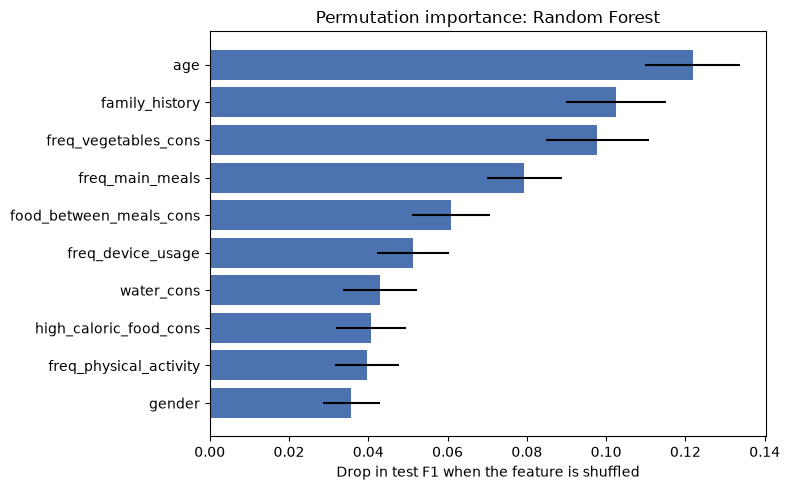

In [6]:
# best model = highest held-out F1 among the real models (baseline excluded)
best = results.drop('Majority-class baseline')['Test F1'].idxmax()
print('Best model:', best)

# permutation importance on the test set (F1 drop, 30 repeats)
pi = permutation_importance(fitted[best], X_test, y_test, scoring='f1',
                            n_repeats=30, random_state=SEED)
imp = pd.DataFrame({'feature': feature_names, 'mean': pi.importances_mean,
                    'std': pi.importances_std}).sort_values('mean', ascending=False)
display(imp.round(4).reset_index(drop=True))

top = imp.head(10).iloc[::-1]
plt.figure(figsize=(8, 5))
plt.barh(top['feature'], top['mean'], xerr=top['std'], color='#4C72B0')
plt.xlabel('Drop in test F1 when the feature is shuffled')
plt.title(f'Permutation importance: {best}')
plt.tight_layout()
plt.show()

## Reading the result

The best model is Random Forest (test F1 about 0.92, ROC AUC 0.97), with XGBoost close behind. The most important features are age, family history of overweight, vegetable intake and number of main meals; smoking and calorie monitoring add nothing.

Caveat: about 77% of rows are SMOTE-synthetic and near-copies of real ones. A random split puts such neighbours in both train and test, so the score is probably optimistic for real people.